# Sydney Housing Price Prediction and Decision Support System

## SIT307 Task 8.1D – Machine Learning Mini Project

This project develops a machine learning system to predict house sale prices in three Sydney suburbs: Penrith, Leichhardt and Turramurra.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## Part 1: Problem Definition and Data Collection

The goal of this project is to develop a machine learning model that can predict the selling price of houses in Sydney. The sale price is the variable we are trying to predict. The input features will be the property and suburb information.

The three selected Sydney suburbs were Penrith, Leichhardt and Turramurra. These suburbs are separate housing markets. Penrith is further from the Sydney CBD and house prices are generally lower. Leichhardt is nearer the CBD and has good access to services and transport. Turramurra is a more expensive residential market. These differences could help the model learn how location and property characteristics affect house prices.

The original data was taken from the publicly available “Sydney House Prices” dataset on Kaggle. For this assessment the data was filtered to only include houses within the three suburbs selected. Final data set consists of 110 sold houses: 32 from Penrith, 36 from Leichhardt and 42 from Turramurra.

In [2]:
file_path = "sydney_three_suburbs_houses.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Number of properties:", df.shape[0])
print("Number of columns:", df.shape[1])

df.head()

Dataset loaded successfully.
Number of properties: 110
Number of columns: 17


,price,date_sold,suburb,num_bath,num_bed,num_parking,property_size,type,suburb_population,suburb_median_income,suburb_sqkm,suburb_lat,suburb_lng,suburb_elevation,cash_rate,property_inflation_index,km_from_cbd
0,1600000,13/2/16,Leichhardt,1,4,0,177,House,14625,56784,2.595,-33.88143,151.15595,31,2.0,150.9,5.31
1,1500000,18/2/16,Leichhardt,2,4,0,177,House,14625,56784,2.595,-33.88143,151.15595,31,2.0,150.9,5.31
2,1265000,19/2/16,Leichhardt,1,3,0,220,House,14625,56784,2.595,-33.88143,151.15595,31,2.0,150.9,5.31
3,925000,27/2/16,Leichhardt,1,2,0,139,House,14625,56784,2.595,-33.88143,151.15595,31,2.0,150.9,5.31
4,1085000,27/2/16,Leichhardt,1,2,1,209,House,14625,56784,2.595,-33.88143,151.15595,31,2.0,150.9,5.31


In [3]:
print("Properties in each suburb:")
print(df["suburb"].value_counts())

Properties in each suburb:
suburb
Turramurra    42
Leichhardt    36
Penrith       32
Name: count, dtype: int64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   price                     110 non-null    int64  
 1   date_sold                 110 non-null    object 
 2   suburb                    110 non-null    object 
 3   num_bath                  110 non-null    int64  
 4   num_bed                   110 non-null    int64  
 5   num_parking               110 non-null    int64  
 6   property_size             110 non-null    int64  
 7   type                      110 non-null    object 
 8   suburb_population         110 non-null    int64  
 9   suburb_median_income      110 non-null    int64  
 10  suburb_sqkm               110 non-null    float64
 11  suburb_lat                110 non-null    float64
 12  suburb_lng                110 non-null    float64
 13  suburb_elevation          110 non-null    int64  
 14  cash_rate 

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price,110.0,NaN,NaN,NaN,1908015.345455,974655.342981,470000.0,1171250.0,1751500.0,2401500.0,4800000.0
date_sold,110,93,27/2/16,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
suburb,110,3,Turramurra,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_bath,110.0,NaN,NaN,NaN,1.890909,0.922158,1.0,1.0,2.0,2.0,5.0
num_bed,110.0,NaN,NaN,NaN,3.545455,1.037254,1.0,3.0,3.0,4.0,6.0
num_parking,110.0,NaN,NaN,NaN,1.545455,1.253519,0.0,1.0,2.0,2.0,8.0
property_size,110.0,NaN,NaN,NaN,733.745455,510.290014,101.0,305.5,711.0,973.75,3307.0
type,110,1,House,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
suburb_population,110.0,NaN,NaN,NaN,13204.890909,1142.623051,11919.0,11919.0,13295.0,14625.0,14625.0
suburb_median_income,110.0,NaN,NaN,NaN,47023.127273,9942.796378,32240.0,32240.0,49920.0,56784.0,56784.0


### Dataset Quality, Challenges and Limitations

The final dataset contains 110 records and 17 original variables. The quality checks found no missing values and no duplicate rows. Every selected suburb has at least 30 properties, which satisfies the minimum data requirement.

The dataset contains useful features such as sale price, sale date, bedrooms, bathrooms, parking spaces, property size, distance from the CBD and suburb information. These variables may help explain differences in house prices.

However, the dataset has some limitations. It contains only houses from three selected suburbs, so the results may not represent the whole Sydney housing market. The sale records cover the period from February 2016 to December 2021. Housing prices and economic conditions may have changed since that period.

There may also be selection bias in the dataset since the records were taken from an already existing online dataset and then sorted. Some important information is missing, like how old the house is, how good the renovations are, where it is on the street and what facilities are nearby. These problems could make the final model less accurate and less useful in other situations.

In [6]:
quality_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique()
})

quality_summary

,Data Type,Missing Values,Unique Values
price,int64,0,98
date_sold,object,0,93
suburb,object,0,3
num_bath,int64,0,5
num_bed,int64,0,6
num_parking,int64,0,8
property_size,int64,0,94
type,object,0,1
suburb_population,int64,0,3
suburb_median_income,int64,0,3


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


## Initial Feature Expectations

Before creating any new features, I expected the following three variables to have the strongest influence on house prices:

1. **Suburb:** Location affects accessibility, local demand, services and distance from the Sydney CBD. Therefore, prices may be different across Penrith, Leichhardt and Turramurra.

2. **Property size:** A larger property normally provides more land and living space. Therefore, larger properties may have higher selling prices.

3. **Number of bedrooms:** Houses with more bedrooms can support larger families and may have greater market value.

These expectations will be compared with the results of the exploratory analysis and machine-learning models.

In [10]:
# Convert the sale date from text into a proper date format
df["date_sold"] = pd.to_datetime(
    df["date_sold"],
    format="%d/%m/%y"
)

# Create year and month features
df["sale_year"] = df["date_sold"].dt.year
df["sale_month"] = df["date_sold"].dt.month

print("Date conversion completed.")
print("Earliest sale date:", df["date_sold"].min())
print("Latest sale date:", df["date_sold"].max())

df[["date_sold", "sale_year", "sale_month"]].head()

print("First five sales:")
display(
    df[["date_sold", "sale_year", "sale_month"]]
    .sort_values("date_sold")
    .head()
)

print("Last five sales:")
display(
    df[["date_sold", "sale_year", "sale_month"]]
    .sort_values("date_sold")
    .tail()
)

Date conversion completed.
Earliest sale date: 2016-02-13 00:00:00
Latest sale date: 2021-12-23 00:00:00
First five sales:


,date_sold,sale_year,sale_month
0,2016-02-13,2016,2
1,2016-02-18,2016,2
2,2016-02-19,2016,2
3,2016-02-27,2016,2
4,2016-02-27,2016,2


Last five sales:


,date_sold,sale_year,sale_month
67,2021-12-04,2021,12
33,2021-12-16,2021,12
109,2021-12-20,2021,12
34,2021-12-21,2021,12
35,2021-12-23,2021,12


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   price                     110 non-null    int64         
 1   date_sold                 110 non-null    datetime64[ns]
 2   suburb                    110 non-null    object        
 3   num_bath                  110 non-null    int64         
 4   num_bed                   110 non-null    int64         
 5   num_parking               110 non-null    int64         
 6   property_size             110 non-null    int64         
 7   type                      110 non-null    object        
 8   suburb_population         110 non-null    int64         
 9   suburb_median_income      110 non-null    int64         
 10  suburb_sqkm               110 non-null    float64       
 11  suburb_lat                110 non-null    float64       
 12  suburb_lng            

## Part 2: Data Understanding and Exploratory Analysis

### 2.1 Distribution of House Sale Prices

This analysis examines the overall distribution of sale prices, including its centre, spread, skewness and possible extreme values.

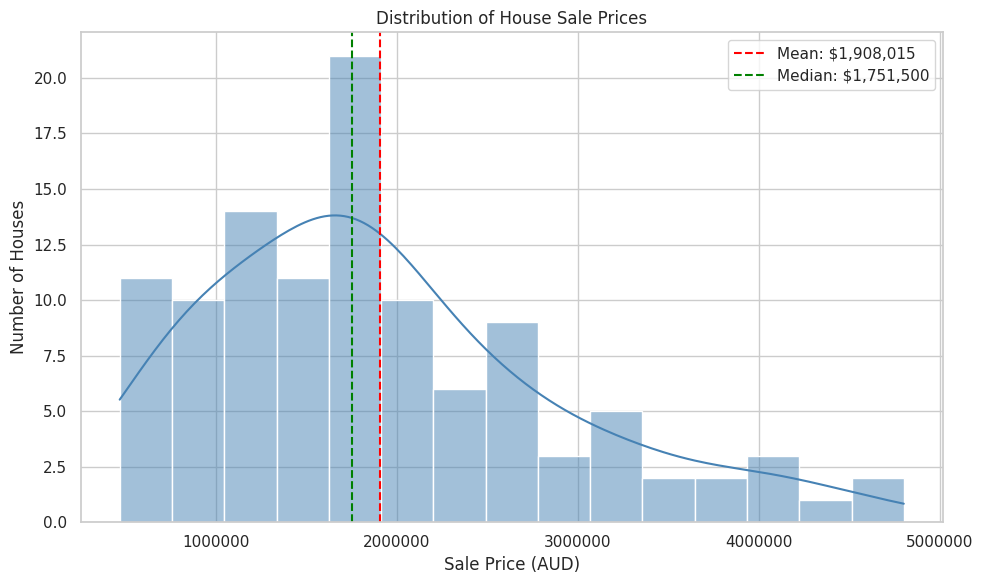

Mean sale price: $1,908,015.35
Median sale price: $1,751,500.00
Minimum sale price: $470,000.00
Maximum sale price: $4,800,000.00
Price skewness: 0.86


In [12]:
mean_price = df["price"].mean()
median_price = df["price"].median()

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="price",
    bins=15,
    kde=True,
    color="steelblue"
)

plt.axvline(
    mean_price,
    color="red",
    linestyle="--",
    label=f"Mean: ${mean_price:,.0f}"
)

plt.axvline(
    median_price,
    color="green",
    linestyle="--",
    label=f"Median: ${median_price:,.0f}"
)

plt.title("Distribution of House Sale Prices")
plt.xlabel("Sale Price (AUD)")
plt.ylabel("Number of Houses")
plt.ticklabel_format(style="plain", axis="x")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean sale price: ${mean_price:,.2f}")
print(f"Median sale price: ${median_price:,.2f}")
print(f"Minimum sale price: ${df['price'].min():,.2f}")
print(f"Maximum sale price: ${df['price'].max():,.2f}")
print(f"Price skewness: {df['price'].skew():.2f}")


The house prices range from AUD 470,000 to AUD 4,800,000. The mean sale price is approximately AUD 1.91 million while the median sale price is approximately AUD 1.75 million.

The mean is higher than the median, and the skewness value is 0.86. Therefore the distribution is moderately right skewed. This means that most houses are found in the lower and middle price ranges, while a smaller number of expensive houses create a long tail on the right side of the graph.

The wide price range may be caused by the different housing markets of Penrith, Leichhardt and Turramurra. The expensive properties may also become outliers and could influence the performance of the prediction models.

### 2.2 House Prices by Suburb

This analysis compares the price distributions of Penrith, Leichhardt and Turramurra. A box plot is used to show the median, spread and possible outliers in each suburb.

,count,mean,median,min,max
suburb,,,,,
Leichhardt,36,1722861.11,1730000.0,925000,2700000
Penrith,32,1104137.12,900500.0,470000,2690000
Turramurra,42,2679197.62,2535500.0,1300000,4800000


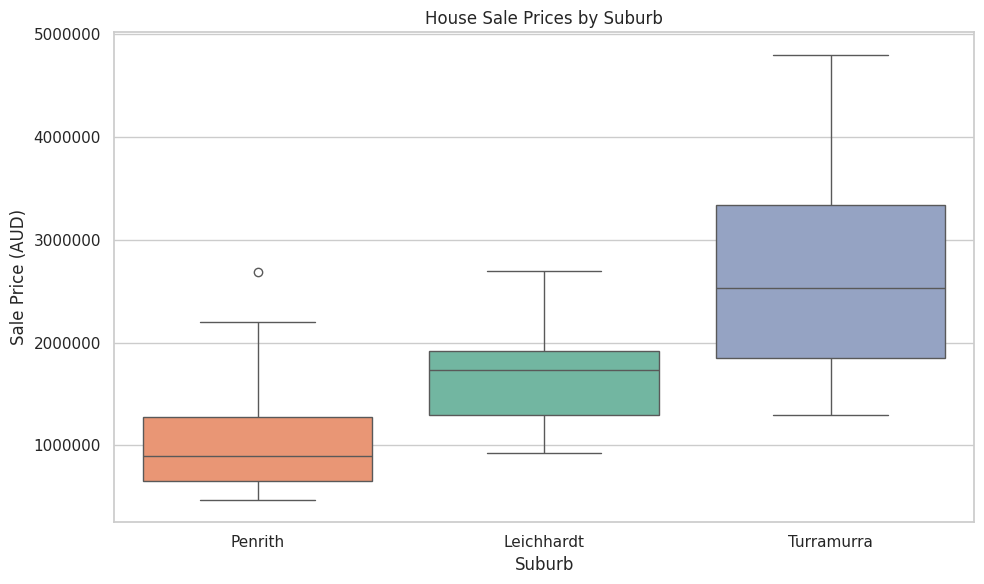

In [13]:
# Calculate price statistics for each suburb
suburb_price_summary = (
    df.groupby("suburb")["price"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(suburb_price_summary)

# Create the box plot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="suburb",
    y="price",
    order=["Penrith", "Leichhardt", "Turramurra"],
    hue="suburb",
    palette="Set2",
    legend=False
)

plt.title("House Sale Prices by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Sale Price (AUD)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

The results show clear differences in house prices among the three suburbs.

Penrith has the lowest median price at AUD 900,500. Its mean price is approximately AUD 1.10 million. Most Penrith houses are in the lower price range. However one house priced at AUD 2.69 million appears as a possible outlier.

Leichhardt has a median price of AUD 1.73 million and a mean price of approximately AUD 1.72 million. Its house prices are generally higher than Penrith but lower than Turramurra.

Turramurra has the highest median price at AUD 2.54 million and the highest mean price at approximately AUD 2.68 million. It also has the widest price range from AUD 1.30 million to AUD 4.80 million.

These results support the initial guess that the suburb is a key factor in figuring out how much a house will cost. Location, services in the area and buyer demand may all play a role in these price differences.

### 2.3 House Price Trends Over Time

This analysis examines how median house prices changed from 2016 to 2021. Median prices are used because they are less affected by very expensive properties and possible outliers.

,sale_year,suburb,price
0,2016,Leichhardt,1265000.0
1,2016,Penrith,2019000.0
2,2016,Turramurra,2180500.0
3,2017,Leichhardt,1682000.0
4,2017,Penrith,648000.0
5,2018,Turramurra,1615000.0
6,2019,Leichhardt,1730000.0
7,2019,Penrith,567500.0
8,2019,Turramurra,1851250.0
9,2020,Leichhardt,2121000.0


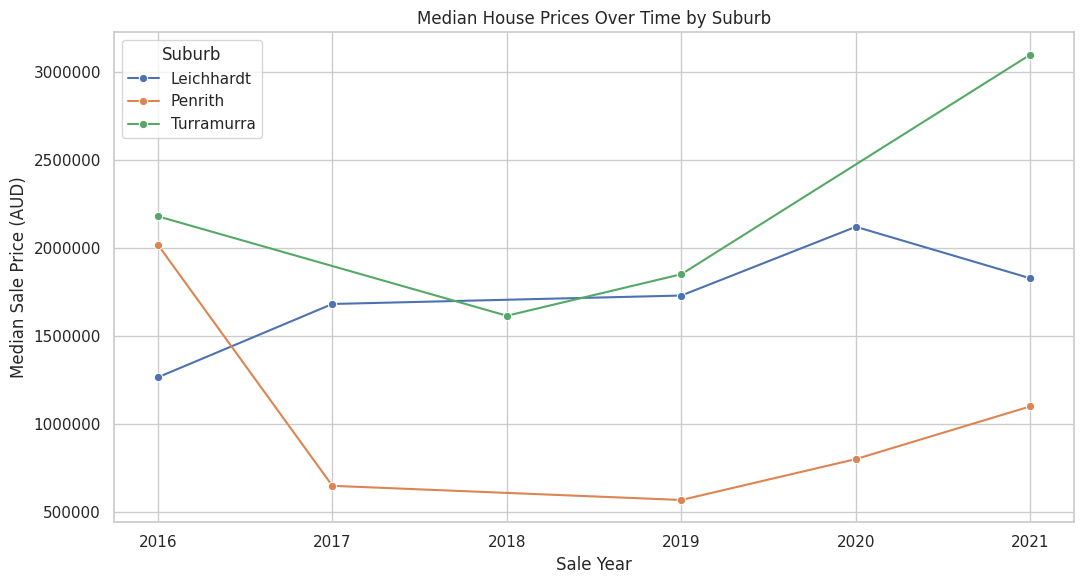

In [14]:
# Calculate yearly median price for each suburb
yearly_prices = (
    df.groupby(["sale_year", "suburb"])["price"]
    .median()
    .reset_index()
)

display(yearly_prices)

# Create the time-trend chart
plt.figure(figsize=(11, 6))

sns.lineplot(
    data=yearly_prices,
    x="sale_year",
    y="price",
    hue="suburb",
    marker="o"
)

plt.title("Median House Prices Over Time by Suburb")
plt.xlabel("Sale Year")
plt.ylabel("Median Sale Price (AUD)")
plt.ticklabel_format(style="plain", axis="y")
plt.legend(title="Suburb")
plt.tight_layout()
plt.show()

The graph shows that median house prices changed over time but the three suburbs followed different patterns.

Leichhardt’s median price generally increased from approximately AUD 1.27 million in 2016 to AUD 2.12 million in 2020. It then decreased slightly to AUD 1.83 million in 2021.

Penrith shows a large fall between 2016 and 2017. However this change should be interpreted carefully because only a small number of Penrith properties may be available for 2016. From 2019 to 2021 its median price increased from approximately AUD 567,500 to AUD 1.10 million.

Turramurra decreased from approximately AUD 2.18 million in 2016 to AUD 1.62 million in 2018. It then increased to AUD 1.85 million in 2019 and AUD 3.10 million in 2021.

Some years do not contain sales for every suburb. Therefore the lines connect years with missing observations and the graph does not represent a continuous yearly trend. The small yearly sample sizes may also create large changes in the median. Despite this limitation the results suggest that sale year may provide useful information for house price prediction.

### 2.4 Identification of Potential Price Outliers

The Interquartile Range (IQR) method is used to identify unusual house prices. A property is treated as a potential outlier when its price is below the lower limit or above the upper limit. Outliers are identified separately within each suburb because the suburbs have different price levels.

In [15]:
# Identify price outliers separately within each suburb
outlier_results = []

for suburb_name, group in df.groupby("suburb"):
    q1 = group["price"].quantile(0.25)
    q3 = group["price"].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    suburb_outliers = group[
        (group["price"] < lower_limit) |
        (group["price"] > upper_limit)
    ].copy()

    suburb_outliers["lower_limit"] = lower_limit
    suburb_outliers["upper_limit"] = upper_limit

    outlier_results.append(suburb_outliers)

price_outliers = pd.concat(outlier_results, ignore_index=True)

print("Number of potential price outliers:", len(price_outliers))

display(
    price_outliers[
        [
            "date_sold",
            "suburb",
            "price",
            "num_bed",
            "num_bath",
            "num_parking",
            "property_size",
            "lower_limit",
            "upper_limit"
        ]
    ].sort_values("price", ascending=False)
)

Number of potential price outliers: 1


,date_sold,suburb,price,num_bed,num_bath,num_parking,property_size,lower_limit,upper_limit
0,2021-04-15,Penrith,2690000,6,2,1,1682,-281250.0,2210750.0


The suburb level IQR method identified one potential price outlier. It is a Penrith house sold on 15 April 2021 for AUD 2,690,000.

The upper price limit calculated for Penrith is AUD 2,210,750. Therefore the sale price of AUD 2,690,000 is classified as an outlier. However this property has six bedrooms and a large property size of 1,682 square metres. These features may provide a reasonable explanation for its high price.

I don’t delete the property at this point as it could be a genuine sale not a data entry error. Removing a valid expensive property will introduce bias and not let the model learn about high value houses. In the model evaluation, we will be looking at how it affects the performance of the model.

### 2.5 Relationships Between Price and Important Variables

Property size and number of bedrooms were initially expected to influence house prices. The following analysis examines their relationships with the sale price. Colours are used to separate the three suburbs.

Correlation between price and property size: 0.409
Correlation between price and bedrooms: 0.459


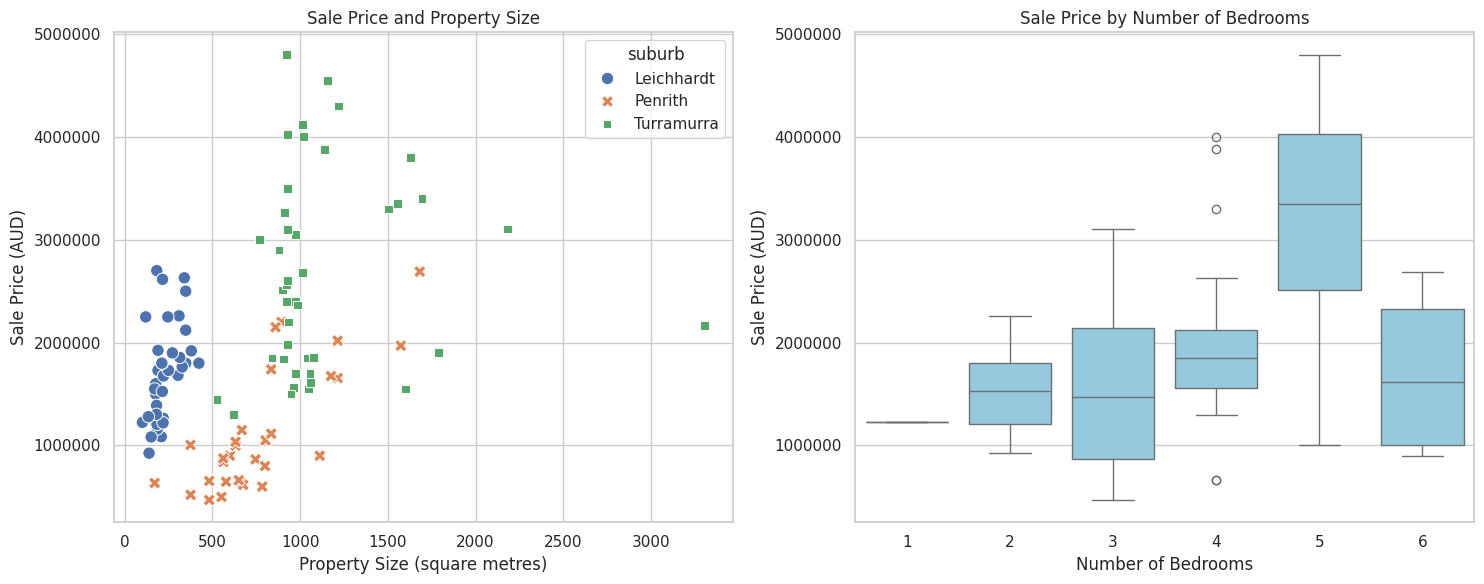

In [16]:
# Calculate correlations with price
size_correlation = df["price"].corr(df["property_size"])
bedroom_correlation = df["price"].corr(df["num_bed"])

print(f"Correlation between price and property size: {size_correlation:.3f}")
print(f"Correlation between price and bedrooms: {bedroom_correlation:.3f}")

# Create two relationship plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Price and property size
sns.scatterplot(
    data=df,
    x="property_size",
    y="price",
    hue="suburb",
    style="suburb",
    s=80,
    ax=axes[0]
)

axes[0].set_title("Sale Price and Property Size")
axes[0].set_xlabel("Property Size (square metres)")
axes[0].set_ylabel("Sale Price (AUD)")
axes[0].ticklabel_format(style="plain", axis="y")

# Price and number of bedrooms
sns.boxplot(
    data=df,
    x="num_bed",
    y="price",
    color="skyblue",
    ax=axes[1]
)

axes[1].set_title("Sale Price by Number of Bedrooms")
axes[1].set_xlabel("Number of Bedrooms")
axes[1].set_ylabel("Sale Price (AUD)")
axes[1].ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()

Property size has a moderate positive correlation of 0.409 with sale price. This means that larger properties generally have higher prices. However the scatter plot shows considerable variation. Properties of similar sizes can have very different prices because suburb and other characteristics also influence their value.

The number of bedrooms has a moderate positive correlation of 0.459 with price. Houses with more bedrooms generally have higher prices. Five bedroom houses have particularly high prices in this dataset. However six bedroom houses do not follow the same clear pattern. This may be caused by the small number of six bedroom properties and differences between suburbs.

The plots also show clear suburb groups. Turramurra properties generally have higher prices, Leichhardt properties are mainly in the middle range and Penrith properties are generally less expensive. Therefore suburb appears to have a stronger and more consistent influence than property size or bedrooms alone.

Correlation does not prove that one variable directly causes a change in price. House prices are affected by several property, location and economic factors together.

### 2.6 Feature Engineering Reflection

Before feature engineering, suburb, property size and number of bedrooms were expected to have the strongest influence on house prices. The exploratory analysis mainly supports these expectations.

The suburb comparison showed large price differences among Penrith, Leichhardt and Turramurra. Property size and bedrooms also had moderate positive relationships with price. However neither variable can explain the complete difference in prices because location and other property characteristics are also important.

The sale date was converted into two new features: sale year and sale month. Sale year may help the models recognise changes in the housing market over time. Sale month may capture possible seasonal differences. These features align with the initial understanding that the time of sale can affect property value.

Additional information could improve the prediction models. Useful features may include the age and condition of the house, renovation status, distance to schools and railway stations, street level location and nearby facilities. These variables were not available in the selected dataset.

Overall the featureengineering decisions are consistent with the initial understanding of the housing market. The engineered time features will be tested with the original property and suburb features during model development.

## Part 3: Model Development and Evaluation

### 3.1 Model Selection and Initial Expectations

Three regression models will be developed and compared in this project.

#### 1. Linear Regression

Linear Regression will be used as a simple baseline model. It assumes that the input features have mainly linear relationships with house prices. It is fast easy to understand and useful for showing how much improvement is achieved by more complex models.

However house prices may contain non linear relationships and interactions. For example the effect of property size may be different in each suburb. Therefore Linear Regression may underfit the data.

#### 2. Random Forest Regressor

Random Forest combines many decision trees to make a final prediction. It can identify non linear relationships and interactions between variables. It is also less affected by individual unusual observations than a single decision tree.

However it is more complex and less easy to interpret than Linear Regression. With a small dataset it may also overfit if the trees are allowed to grow too deeply.

#### 3. Gradient Boosting Regressor

Gradient Boosting builds decision trees one after another. Each new tree attempts to correct errors made by the previous trees. It can model complex relationships and may provide accurate predictions.

However it can overfit if too many trees or excessive complexity are used. It can also be sensitive to its parameter settings.

#### Expected Best Model

I expect Random Forest to do the best before training. In the exploratory analysis, it was found that house prices are influenced by several interacting factors such as suburb, property size, bedrooms and sale year. Random Forest is able to model such complex relationships without assuming them to be linear.

Gradient Boosting may also perform well but it may be more sensitive to the small dataset. Linear Regression is expected to provide the weakest performance because the housing market contains non-linear relationships and unusual properties.

The models will be evaluated using five fold cross validation. Mean Absolute Error, Root Mean Squared Error and R-squared will be used as the main regression metrics.

### 3.2 Feature Selection and Data Preparation

The target variable is price. The predictors include the property characteristics, suburb, sale timing and relevant economic conditions.

The selected numerical features are bedrooms, bathrooms, parking spaces, property size, sale year, sale month, cash rate and property inflation index. Suburb is included as a categorical feature.

The original sale date is excluded because its year and month have already been extracted. Property type is excluded because every observation is a house and therefore it provides no variation. Suburb-level variables such as population, coordinates and distance from the CBD are excluded because each is constant within a suburb and largely duplicates the information represented by the suburb variable.

Numerical features are standardised, while suburb is converted into numerical dummy variables using one-hot encoding. This preprocessing is placed inside each modelling pipeline to prevent information leakage during cross-validation.

In [17]:
# Import modelling and preprocessing tools
from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Define the target
y = df["price"]

# Select predictor variables
numeric_features = [
    "num_bath",
    "num_bed",
    "num_parking",
    "property_size",
    "sale_year",
    "sale_month",
    "cash_rate",
    "property_inflation_index"
]

categorical_features = ["suburb"]

feature_columns = numeric_features + categorical_features
X = df[feature_columns].copy()

# Create the preprocessing procedure
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        )
    ]
)

print("Target variable: price")
print("Number of observations:", X.shape[0])
print("Number of original predictors:", X.shape[1])
print("\nSelected predictors:")
print(feature_columns)

display(X.head())

Target variable: price
Number of observations: 110
Number of original predictors: 9

Selected predictors:
['num_bath', 'num_bed', 'num_parking', 'property_size', 'sale_year', 'sale_month', 'cash_rate', 'property_inflation_index', 'suburb']


,num_bath,num_bed,num_parking,property_size,sale_year,sale_month,cash_rate,property_inflation_index,suburb
0,1,4,0,177,2016,2,2.0,150.9,Leichhardt
1,2,4,0,177,2016,2,2.0,150.9,Leichhardt
2,1,3,0,220,2016,2,2.0,150.9,Leichhardt
3,1,2,0,139,2016,2,2.0,150.9,Leichhardt
4,1,2,1,209,2016,2,2.0,150.9,Leichhardt


### 3.3 Model Training and Five-Fold Cross-Validation

The three regression models are evaluated using five-fold cross-validation. The dataset is divided into five parts. Each model is trained using four parts and tested using the remaining part. This process is repeated five times so that every observation is used for testing once.

The models are compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE) and R-squared. Lower MAE and RMSE values indicate smaller prediction errors. A higher R-squared value indicates that the model explains more of the variation in house prices.

In [18]:
# Create the three modelling pipelines
models = {
    "Linear Regression": Pipeline([
        ("preprocessing", preprocessor),
        ("model", LinearRegression())
    ]),

    "Random Forest": Pipeline([
        ("preprocessing", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=2,
            random_state=42
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("preprocessing", preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=2,
            random_state=42
        ))
    ])
}

# Create five-fold cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Define the evaluation metrics
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

# Evaluate every model
comparison_rows = []

for model_name, model in models.items():

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

    comparison_rows.append({
        "Model": model_name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R2": scores["test_R2"].mean(),
        "Train RMSE": -scores["train_RMSE"].mean(),
        "Train R2": scores["train_R2"].mean(),
        "R2 Standard Deviation": scores["test_R2"].std()
    })

# Create the comparison table
model_results = pd.DataFrame(comparison_rows)

# Sort from the lowest cross-validation RMSE
model_results = model_results.sort_values(
    "CV RMSE"
).reset_index(drop=True)

# Create a formatted display copy
display_results = model_results.copy()

money_columns = ["CV MAE", "CV RMSE", "Train RMSE"]
display_results[money_columns] = display_results[money_columns].round(2)

score_columns = ["CV R2", "Train R2", "R2 Standard Deviation"]
display_results[score_columns] = display_results[score_columns].round(3)

display(display_results)

print(
    "Best model based on the lowest CV RMSE:",
    model_results.iloc[0]["Model"]
)

,Model,CV MAE,CV RMSE,CV R2,Train RMSE,Train R2,R2 Standard Deviation
0,Random Forest,370055.96,502239.81,0.674,271243.50,0.921,0.196
1,Gradient Boosting,388481.55,521575.17,0.651,262376.05,0.926,0.214
2,Linear Regression,423674.60,555314.89,0.621,447529.44,0.785,0.170


Best model based on the lowest CV RMSE: Random Forest


### 3.4 Model Performance Analysis

Random Forest produced the best cross validation results. It achieved an MAE of approximately AUD 370,056, an RMSE of approximately AUD 502,230 and an R squared value of 0.674. This means that it explained about 67.4% of the variation in house prices.

Gradient Boosting produced the second-best result with an RMSE of approximately AUD 521,575 and an R squared value of 0.651. Linear Regression had the weakest performance. Its RMSE was approximately AUD 555,315 and its R squared value was 0.621.

The lower performance of Linear Regression suggests that the relationships between property characteristics and prices are not completely linear. Therefore Linear Regression may be underfitting some complex patterns in the data.

Random Forest and Gradient Boosting had much better training results than cross validation results. For example Random Forest had a training R squared value of 0.921 but a cross validation R squared value of 0.674. This difference suggests some overfitting. Gradient Boosting showed a similar pattern. This happened because the tree based models are more complex and can learn the training observations closely.

However Random Forest still produced the lowest cross validation prediction errors. Its R squared standard deviation was also lower than that of Gradient Boosting showing slightly more stable performance across the five folds.

The original expectation that Random Forest would perform best was supported by the experimental results. Therefore Random Forest is recommended as the most appropriate model. It provides the best balance between prediction accuracy, stability and the ability to capture non-linear relationships. However, its predictions should still be interpreted carefully because the dataset contains only 110 properties and some evidence of overfitting remains.

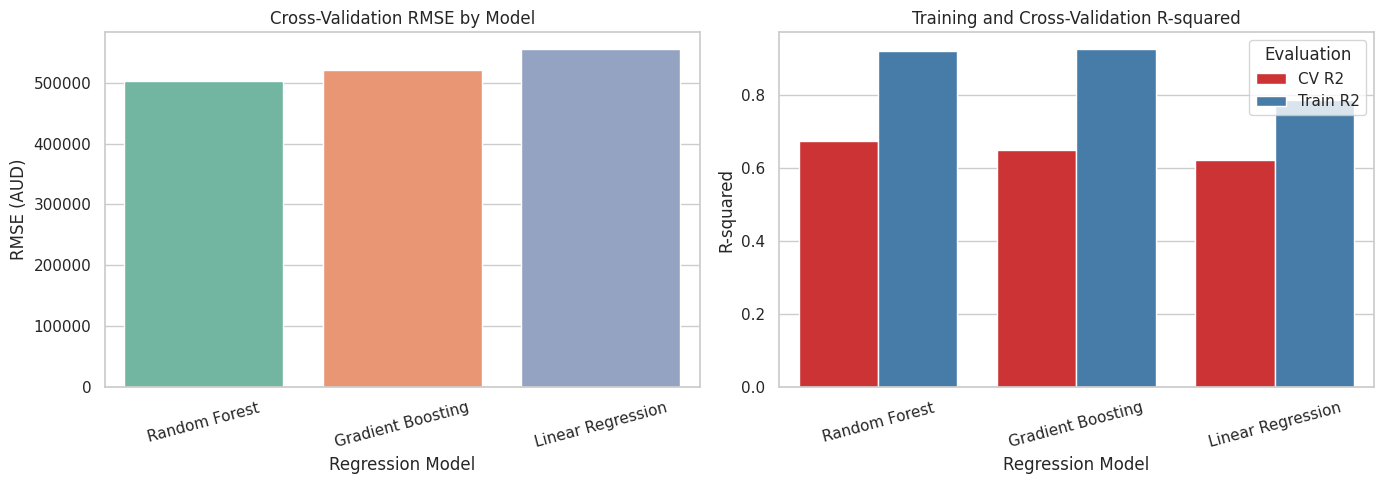

In [19]:
# Create charts to compare model performance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compare cross-validation RMSE
sns.barplot(
    data=model_results,
    x="Model",
    y="CV RMSE",
    hue="Model",
    palette="Set2",
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Cross-Validation RMSE by Model")
axes[0].set_xlabel("Regression Model")
axes[0].set_ylabel("RMSE (AUD)")
axes[0].ticklabel_format(style="plain", axis="y")
axes[0].tick_params(axis="x", rotation=15)

# Compare training and cross-validation R-squared
r2_comparison = model_results[
    ["Model", "CV R2", "Train R2"]
].melt(
    id_vars="Model",
    var_name="Evaluation",
    value_name="R-squared"
)

sns.barplot(
    data=r2_comparison,
    x="Model",
    y="R-squared",
    hue="Evaluation",
    palette="Set1",
    ax=axes[1]
)

axes[1].set_title("Training and Cross-Validation R-squared")
axes[1].set_xlabel("Regression Model")
axes[1].set_ylabel("R-squared")
axes[1].tick_params(axis="x", rotation=15)
axes[1].legend(title="Evaluation")

plt.tight_layout()
plt.show()

## Part 4: Investigating Prediction Failures

### 4.1 Identifying the Five Largest Prediction Errors

The Random Forest model was selected because it produced the best cross-validation performance. To investigate its prediction failures, cross-validated predictions are created for all 110 properties.

Each property is predicted by a model that was not trained using that property. This provides a fairer estimate of prediction error. The absolute error is calculated as the difference between the actual price and predicted price. The five properties with the largest absolute errors are then examined in detail.

In [20]:
# Import the function for cross-validated predictions
from sklearn.model_selection import cross_val_predict

# Select the recommended model
best_model = models["Random Forest"]

# Produce out-of-fold predictions for all properties
cv_predictions = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv
)

# Create a dataset for prediction-error analysis
failure_analysis = df.copy()

failure_analysis["predicted_price"] = cv_predictions

# Positive error means the model underestimated the price
# Negative error means the model overestimated the price
failure_analysis["prediction_error"] = (
    failure_analysis["price"]
    - failure_analysis["predicted_price"]
)

failure_analysis["absolute_error"] = (
    failure_analysis["prediction_error"].abs()
)

failure_analysis["percentage_error"] = (
    failure_analysis["absolute_error"]
    / failure_analysis["price"]
    * 100
)

# Select the five properties with the largest errors
largest_errors = (
    failure_analysis
    .sort_values("absolute_error", ascending=False)
    .head(5)
    .copy()
)

# Add the direction of each error
largest_errors["error_direction"] = largest_errors[
    "prediction_error"
].apply(
    lambda value: "Underestimated"
    if value > 0
    else "Overestimated"
)

# Select important columns for display
error_columns = [
    "date_sold",
    "suburb",
    "price",
    "predicted_price",
    "absolute_error",
    "percentage_error",
    "error_direction",
    "num_bed",
    "num_bath",
    "num_parking",
    "property_size",
    "sale_year"
]

# Format a copy for clear presentation
largest_errors_display = largest_errors[error_columns].copy()

money_columns = [
    "price",
    "predicted_price",
    "absolute_error"
]

largest_errors_display[money_columns] = (
    largest_errors_display[money_columns].round(2)
)

largest_errors_display["percentage_error"] = (
    largest_errors_display["percentage_error"].round(2)
)

largest_errors_display = largest_errors_display.reset_index(
    names="original_row"
)

display(largest_errors_display)

,original_row,date_sold,suburb,price,predicted_price,absolute_error,percentage_error,error_direction,num_bed,num_bath,num_parking,property_size,sale_year
0,68,2016-11-17,Turramurra,3880000,1786022.27,2093977.73,53.97,Underestimated,4,2,2,1140,2016
1,106,2021-11-27,Turramurra,4025000,2489254.54,1535745.46,38.16,Underestimated,5,2,2,930,2021
2,37,2017-09-19,Penrith,900000,2357310.25,1457310.25,161.92,Overestimated,6,2,2,1112,2017
3,72,2016-11-26,Turramurra,3105000,1781924.00,1323076.00,42.61,Underestimated,3,2,2,2183,2016
4,74,2018-05-25,Turramurra,1550000,2830540.65,1280540.65,82.62,Overestimated,4,2,2,1600,2018


### 4.2 Investigation of the Five Largest Errors

#### Property 1 – Turramurra, 17 November 2016

This property had an actual price of AUD 3,880,000 but the model predicted approximately AUD 1,786,022. The model underestimated the price by approximately AUD 2,093,978 or 53.97%.

The property has four bedrooms, two bathrooms, two parking spaces and a property size of 1,140 square metres. Its high selling price may have been influenced by features that are not available in the dataset. These may include a renovated interior, modern design, high construction quality, swimming pool, attractive views, school access or a valuable street location.

#### Property 2 – Turramurra, 27 November 2021

This property sold for AUD 4,025,000, while the predicted price was approximately AUD 2,489,255. The model underestimated its price by approximately AUD 1,535,745, or 38.16%.

It has five bedrooms, two bathrooms, two parking spaces and a property size of 930 square metres. The model recognised some of its value but could not fully explain its high price. The sale may have been affected by its condition, architectural quality, renovations or strong buyer competition during the sale.

#### Property 3 – Penrith, 19 September 2017

The model predicted a price of approximately AUD 2,357,310 for this property but the actual price was AUD 900,000. The model was over optimistic in price by about AUD 1,457,310. This is a percentage error of 161.92% and is the largest percentage error of the five properties.

The property has six bedrooms, two bathrooms, two parking spaces and a size of 1,112 square metres. These characteristics normally suggest a high value property. However its actual price was much lower than expected. Possible explanations include poor condition an undesirable street location, required repairs, unusual land use, an urgent sale or an incorrect data record. The model could not observe these factors.

#### Property 4 – Turramurra, 26 November 2016

This property sold for AUD 3,105,000 while the model predicted approximately AUD 1,781,924. Its price was underestimated by approximately AUD 1,323,076, or 42.61%.

It has three bedrooms, two bathrooms, two parking spaces and a large property size of 2,183 square metres. The model may not have fully captured the value of its large land area. Its value may also have been influenced by redevelopment potential, subdivision opportunities or a desirable location within Turramurra.

#### Property 5 – Turramurra, 25 May 2018

This property had an actual price of AUD 1,550,000 while the model predicted approximately AUD 2,830,541. The model overestimated its value by approximately AUD 1,280,541 or 82.62%.

It has a built up area of 1,600 sq m and has four bedrooms, two bathrooms and two parking spaces. The model expected a higher price because of the Turramurra location and the size of the property. However the sale price may have been reduced by the poor condition of the property damage to the building, an inconvenient location, development restrictions or unusual conditions of sale.

### 4.3 Limitations and Cautious Interpretation

The results show that property size, bedrooms and suburb are not enough to explain every selling price. The dataset does not include property age, building condition, renovation quality, exact address, street quality, school zones, distance to a railway station, views, noise levels or the reason for the sale. These missing factors may explain many of the large errors.

Luxury properties, unusually large properties, properties requiring repairs and properties sold under special conditions are more difficult to predict. These properties may be very different from the usual observations used to train the model.

Housing-price predictions should therefore be interpreted carefully when a property is unusual or when important information is unavailable. The model provides an estimate based on historical patterns, but it should not replace a professional property valuation or detailed inspection.

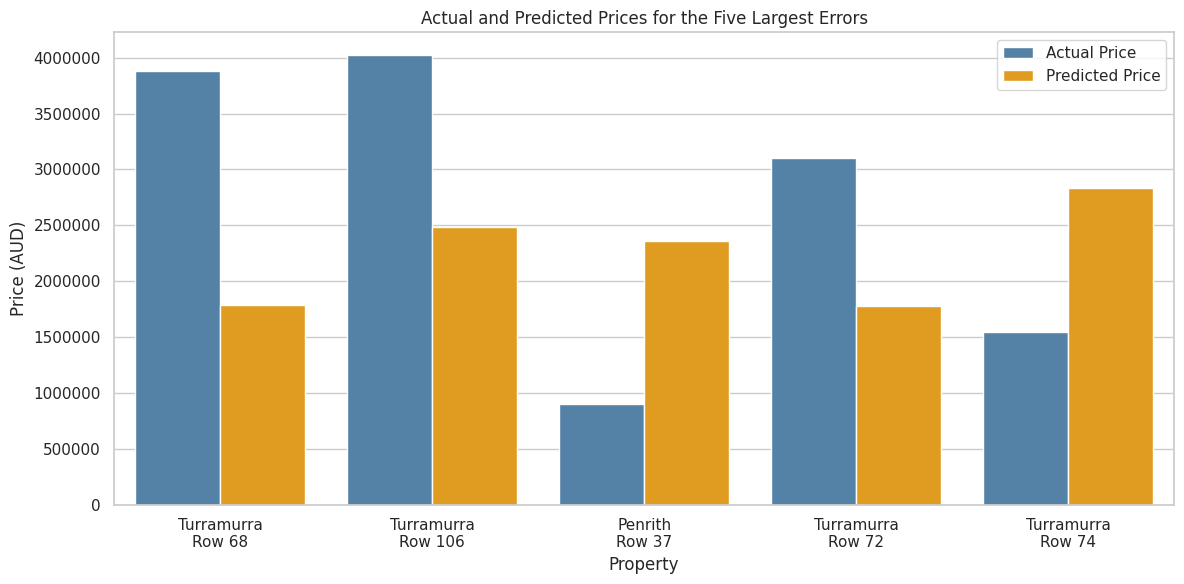

In [21]:
# Create labels for the five properties
plot_errors = largest_errors_display.copy()

plot_errors["property_label"] = (
    plot_errors["suburb"]
    + "\nRow "
    + plot_errors["original_row"].astype(str)
)

# Convert actual and predicted prices into long format
price_comparison = plot_errors[
    ["property_label", "price", "predicted_price"]
].melt(
    id_vars="property_label",
    var_name="Price Type",
    value_name="Price"
)

price_comparison["Price Type"] = price_comparison[
    "Price Type"
].replace({
    "price": "Actual Price",
    "predicted_price": "Predicted Price"
})

# Create the comparison chart
plt.figure(figsize=(12, 6))

sns.barplot(
    data=price_comparison,
    x="property_label",
    y="Price",
    hue="Price Type",
    palette=["steelblue", "orange"]
)

plt.title("Actual and Predicted Prices for the Five Largest Errors")
plt.xlabel("Property")
plt.ylabel("Price (AUD)")
plt.ticklabel_format(style="plain", axis="y")
plt.legend(title="")
plt.tight_layout()
plt.show()

## Part 5: Final Deployment and Reflection

### 5.1 Preparing the Final Model for Deployment

Random Forest was selected as the final model because it produced the lowest cross-validation RMSE and the highest cross-validation R-squared value. The final pipeline includes both data preprocessing and the Random Forest model.

For deployment, the model is trained using all 110 available properties. It is then saved as a file that can be loaded by the Streamlit application. This allows the application to accept property information and return an estimated sale price without training the model again.

In [22]:
# Import the library used to save the model
import joblib

# Select the recommended Random Forest pipeline
final_model = models["Random Forest"]

# Train the final model using all available properties
final_model.fit(X, y)

# Save the complete preprocessing and prediction pipeline
joblib.dump(
    final_model,
    "house_price_model.pkl"
)

print("Final Random Forest model trained successfully.")
print("Model saved as: house_price_model.pkl")
print("Training observations:", X.shape[0])
print("Model input features:", list(X.columns))

Final Random Forest model trained successfully.
Model saved as: house_price_model.pkl
Training observations: 110
Model input features: ['num_bath', 'num_bed', 'num_parking', 'property_size', 'sale_year', 'sale_month', 'cash_rate', 'property_inflation_index', 'suburb']


### 5.2 Developing the Streamlit Web Application

A Streamlit web application was developed to provide a simple interface for generating house-price predictions. Users select the suburb, property characteristics, sale period and relevant economic conditions. When the prediction button is pressed, the application places these values into a dataframe with the same structure used during model training.

The saved pipeline performs the required preprocessing and uses the trained Random Forest model to estimate the sale price. The application also displays a warning explaining that the result is an estimate based on a small historical dataset.


In [23]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="Sydney House Price Predictor",
    page_icon="🏠",
    layout="centered"
)

@st.cache_resource
def load_model():
    return joblib.load("house_price_model.pkl")

model = load_model()

st.title("Sydney House Price Predictor")
st.write(
    "Enter the property information below to estimate its sale price."
)

with st.form("prediction_form"):
    suburb = st.selectbox(
        "Suburb",
        ["Penrith", "Leichhardt", "Turramurra"]
    )

    num_bed = st.number_input(
        "Number of bedrooms",
        min_value=1,
        max_value=10,
        value=3,
        step=1
    )

    num_bath = st.number_input(
        "Number of bathrooms",
        min_value=1,
        max_value=6,
        value=2,
        step=1
    )

    num_parking = st.number_input(
        "Number of parking spaces",
        min_value=0,
        max_value=10,
        value=1,
        step=1
    )

    property_size = st.number_input(
        "Property size (square metres)",
        min_value=50,
        max_value=4000,
        value=600,
        step=10
    )

    sale_year = st.selectbox(
        "Sale year",
        list(range(2016, 2022)),
        index=5
    )

    sale_month = st.selectbox(
        "Sale month",
        list(range(1, 13))
    )

    cash_rate = st.number_input(
        "Cash rate (%)",
        min_value=0.0,
        max_value=10.0,
        value=0.10,
        step=0.10,
        format="%.2f"
    )

    property_inflation_index = st.number_input(
        "Property inflation index",
        min_value=100.0,
        max_value=300.0,
        value=180.0,
        step=0.1,
        format="%.1f"
    )

    submitted = st.form_submit_button("Predict Sale Price")

if submitted:
    input_data = pd.DataFrame({
        "num_bath": [num_bath],
        "num_bed": [num_bed],
        "num_parking": [num_parking],
        "property_size": [property_size],
        "sale_year": [sale_year],
        "sale_month": [sale_month],
        "cash_rate": [cash_rate],
        "property_inflation_index": [property_inflation_index],
        "suburb": [suburb]
    })

    predicted_price = model.predict(input_data)[0]

    st.success(
        f"Estimated sale price: AUD ${predicted_price:,.0f}"
    )

    st.subheader("Entered Property Information")
    st.dataframe(input_data, hide_index=True)

st.warning(
    "This estimate is based on 110 historical sales from 2016–2021. "
    "It should not replace a professional property valuation."
)

Writing app.py


In [24]:
%%writefile requirements.txt

streamlit
pandas
scikit-learn
joblib

Writing requirements.txt


In [25]:
import os

deployment_files = [
    "app.py",
    "requirements.txt",
    "house_price_model.pkl"
]

for file in deployment_files:
    print(file, "— Found" if os.path.exists(file) else "— Missing")

app.py — Found
requirements.txt — Found
house_price_model.pkl — Found


In [26]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 82.6 MB/s eta 0:00:00


In [27]:
import joblib
import pandas as pd

test_model = joblib.load("house_price_model.pkl")

test_property = pd.DataFrame({
    "num_bath": [2],
    "num_bed": [3],
    "num_parking": [1],
    "property_size": [600],
    "sale_year": [2021],
    "sale_month": [6],
    "cash_rate": [0.10],
    "property_inflation_index": [180.0],
    "suburb": ["Penrith"]
})

test_prediction = test_model.predict(test_property)[0]

print(f"Test prediction: AUD ${test_prediction:,.0f}")
print("Model and application inputs are working successfully.")

Test prediction: AUD $892,140
Model and application inputs are working successfully.


In [28]:
!python -m py_compile app.py
print("app.py passed the syntax check.")

app.py passed the syntax check.


In [29]:
!pip install -q pyngrok

In [31]:
from pyngrok import ngrok

ngrok.set_auth_token("3JWw154unXqSnF2uB5mA9DBXTal_5HYDVfHFWSk7ymfBrGAAx")

print("Ngrok authentication completed successfully.")

Ngrok authentication completed successfully.


In [32]:
import subprocess
import time
from pyngrok import ngrok

ngrok.kill()

process = subprocess.Popen([
    "streamlit",
    "run",
    "app.py",
    "--server.port",
    "8501",
    "--server.headless",
    "true"
])

time.sleep(5)

public_url = ngrok.connect(8501)

print("Open the Streamlit application here:")
print(public_url.public_url)

Open the Streamlit application here:
https://resample-ovary-wiring.ngrok-free.dev


### 5.3 Application Testing and User Instructions

The application was tested on a Penrith property that has three bedrooms, two bathrooms, one parking space and a property size of 600 square metres. The chosen sales period was January 2021. The application valued the sale price at $891,981AUD. This confirmed that the saved model, preprocessing pipeline and web interface were working properly.

#### Instructions for Using the Application

1. Open the application using the provided web link.
2. Select Penrith, Leichhardt or Turramurra as the suburb.
3. Enter the number of bedrooms, bathrooms and parking spaces.
4. Enter the property size in square metres.
5. Select the sale year and sale month.
6. Enter the cash rate and property inflation index.
7. Click the Predict Sale Price button.
8. Read the estimated sale price displayed below the form.

The prediction is based on 110 historical sales between 2016 and 2021. Accordingly the outcome should be treated as an approximation and not a replacement for a professional valuation of the property.

### 5.4 Reflection on the Complete Machine Learning Workflow

In this project, I went through the entire machine learning pipeline from collecting and preparing the housing data to evaluating models and building a web app. A main lesson was that the performance of the model is very dependent on the quality, quantity and relevance of the available data. The data set was clean but limited to 110 properties from three suburbs in Sydney limiting the patterns that the models could learn.

Data collection was challenging because consistent historical information was not available for every property. Important factors such as building age, condition, renovation quality, exact street location, school zone, proximity to transport, views and sale circumstances were unavailable. These missing variables probably explain some of the large prediction errors found in Part 4.

During preprocessing sale dates were converted into year and month features, numerical variables were standardised and suburb was one-hot encoded. Placing these operations inside the modelling pipelines helped prevent data leakage during cross validation. Feature engineering also showed that economic variables such as the cash rate and property inflation index may provide useful market context. However the small dataset made it difficult to measure their individual effects reliably.

Three regression approaches were compared. Linear Regression was transparent and easy to interpret but it could not represent all the non linear relationships in the data. Random Forest and Gradient Boosting captured more complex interactions and achieved better cross validation results. Random Forest was selected because it produced the lowest cross validation RMSE and the highest cross validation R squared value. However the difference between its training and cross validation performance indicated some overfitting. This demonstrated that the model with the strongest training performance is not necessarily the model that will perform best on unseen properties.

There was also a trade off between predictive performance and practical deployment. Random Forest was less interpretable than Linear Regression but its complete preprocessing and prediction pipeline could be saved and loaded easily by the Streamlit application. The application provides a convenient interface but users must enter economic variables that they may not know. In a future version these values could be automatically obtained from a maintained economic dataset based on the selected sale date.

The data may contain geographical and economic biases. Only Penrith, Leichhardt and Turramurra were included, so the model should not be used to predict prices in other suburbs. The small and uneven sample may also represent some price ranges or property types better than others. If predictions were used for lending, taxation or investment decisions, inaccurate estimates could disadvantage particular owners or neighbourhoods. Therefore the result should be treated as an approximate decision-supporte stimate rather than an official valuation.

With additional time and resources this project could be improved by collecting more recent sales from a wider range of suburbs and adding information about property condition, age, exact location, transport access, school zones and renovation quality. Hyperparameter tuning and repeated or nested cross validation could provide a more reliable model comparison. Other algorithms, including XGBoost or CatBoost could also be evaluated. Prediction intervals could be added so that the application communicates uncertainty instead of presenting only a single price.

Overall, the project successfully developed, evaluated and deployed a working house-price prediction system. The final model captured useful historical patterns, but the error analysis showed that housing prices are affected by many factors that were not present in the dataset. The application is therefore useful as a demonstration and preliminary estimate, while professional valuation and additional property information remain necessary for important real-world decisions.